In [5]:
import cv2
import numpy as np
from facenet_pytorch import MTCNN
from PIL import Image
import torch

# Image path
image_path = "/kaggle/input/verification2/national_id.jpg"

# Load and convert image to RGB
image_original = Image.open(image_path).convert("RGB")
original_size = image_original.size  # (width, height)

# Resize image to improve face detection
resize_width = 512
resize_height = int(resize_width * original_size[1] / original_size[0])
image_resized = image_original.resize((resize_width, resize_height))

# Apply histogram equalization to enhance contrast
gray = cv2.cvtColor(np.array(image_resized), cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray)
rgb_equalized = cv2.cvtColor(equalized, cv2.COLOR_GRAY2RGB)
image_for_detection = Image.fromarray(rgb_equalized)

# Initialize MTCNN face detector
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=True, device=device)

# Detect faces
boxes, _ = mtcnn.detect(image_for_detection)

if boxes is not None:
    print(f"Detected {len(boxes)} face(s).")

    # Scale boxes back to original image size
    scale_x = original_size[0] / resize_width
    scale_y = original_size[1] / resize_height
    boxes_scaled = boxes * [scale_x, scale_y, scale_x, scale_y]

    image_bgr = cv2.cvtColor(np.array(image_original), cv2.COLOR_RGB2BGR)

    for i, box in enumerate(boxes_scaled):
        x1, y1, x2, y2 = [int(coord) for coord in box]
        face_crop = image_bgr[y1:y2, x1:x2]
        cv2.imwrite(f"face_{i+1}.jpg", face_crop)
        print(f"Saved: face_{i+1}.jpg")

else:
    print("No faces detected with MTCNN. Trying OpenCV...")

    # Convert image to grayscale for OpenCV
    image_bgr = cv2.cvtColor(np.array(image_original), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) > 0:
        for i, (x, y, w, h) in enumerate(faces):
            face_crop = image_bgr[y:y+h, x:x+w]
            cv2.imwrite(f"face_opencv_{i+1}.jpg", face_crop)
            print(f"Saved: face_opencv_{i+1}.jpg")
    else:
        print("No faces detected with OpenCV either.")


Detected 1 face(s).
Saved: face_1.jpg


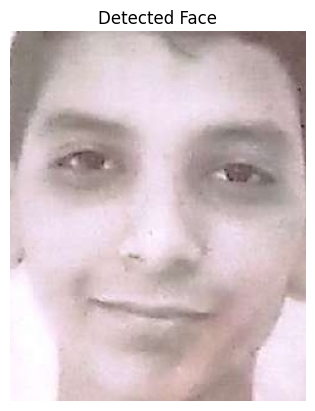

In [6]:
import cv2
import matplotlib.pyplot as plt

image_path = "/kaggle/working/face_1.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct colors

plt.imshow(image_rgb)
plt.axis('off')
plt.title("Detected Face")
plt.show()


In [2]:
!pip install facenet-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 19.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 3.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 28.1 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 12.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install --upgrade Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 78.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 11.3.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
bigframes 2.8.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.8.0 requires rich<14,>=12.4.4, but y

In [7]:
import torch
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
import cv2
from sklearn.metrics.pairwise import cosine_similarity

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load MTCNN for face detection and ResNet for embeddings
mtcnn = MTCNN(image_size=160, margin=0, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# Function to extract embedding from an image
def get_embedding(image_path):
    image = Image.open(image_path).convert('RGB')
    face = mtcnn(image)
    
    if face is not None:
        face = face.unsqueeze(0).to(device)  # Add batch dimension
        embedding = resnet(face)
        return embedding
    else:
        print(f"Face not found in {image_path}")
        return None

# Image paths
id_path = "/kaggle/working/face_1.jpg"  # ID photo (cropped face)
real_path = "/kaggle/input/verification2/IMG_20250718_101118.jpg"  # Real person photo

# Get face embeddings
id_embedding = get_embedding(id_path)
real_embedding = get_embedding(real_path)

# Compare faces if both embeddings are available
if id_embedding is not None and real_embedding is not None:
    similarity = cosine_similarity(
        id_embedding.cpu().detach().numpy(),
        real_embedding.cpu().detach().numpy()
    )[0][0]

    print(f"Cosine Similarity: {similarity:.4f}")
    
    if similarity > 0.7:
        print("Match: Likely the same person ")
    else:
        print("No match: Likely different persons ")


  0%|          | 0.00/107M [00:00<?, ?B/s]

Cosine Similarity: 0.7380
Match: Likely the same person 


In [8]:
!apt-get update
!apt-get install -y tesseract-ocr-ara


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,840 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,470 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/p

In [ ]:
import cv2
import numpy as np
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import torch
import pytesseract
from sklearn.metrics.pairwise import cosine_similarity
import re

# File paths
id_image_path = "/kaggle/input/verification2/national_id.jpg"
live_photo_path = "/kaggle/input/verification2/IMG_20250718_101118.jpg"
face_from_id_path = "/kaggle/working/face_from_id.jpg"

# Initialize models
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=True, device=device)
embedder = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# Step 1 - Try to detect the face from the ID card
original_img = Image.open(id_image_path).convert("RGB")
orig_w, orig_h = original_img.size

# Resize the image to help detection
resized_w = 512
resized_h = int(resized_w * orig_h / orig_w)
resized_img = original_img.resize((resized_w, resized_h))

# Apply histogram equalization to improve contrast
gray_img = cv2.cvtColor(np.array(resized_img), cv2.COLOR_RGB2GRAY)
eq_img = cv2.equalizeHist(gray_img)
color_img = cv2.cvtColor(eq_img, cv2.COLOR_GRAY2RGB)
pil_img = Image.fromarray(color_img)

# Detect face
boxes, _ = mtcnn.detect(pil_img)

if boxes is not None:
    print(f"{len(boxes)} face(s) detected in the ID image.")

    # Rescale the box back to the original size
    scale_x = orig_w / resized_w
    scale_y = orig_h / resized_h
    boxes = boxes * [scale_x, scale_y, scale_x, scale_y]

    bgr_img = cv2.cvtColor(np.array(original_img), cv2.COLOR_RGB2BGR)
    x1, y1, x2, y2 = [int(i) for i in boxes[0]]
    face_crop = bgr_img[y1:y2, x1:x2]
    cv2.imwrite(face_from_id_path, face_crop)
    print("Face from ID saved successfully.")
else:
    print("No face found in ID image.")
    exit()

# Step 2 - Generate embeddings from both ID face and live photo
def get_embedding(path):
    img = Image.open(path).convert("RGB")
    face = mtcnn(img)

    if face is not None:
        if face.dim() == 3:
            face = face.unsqueeze(0)
        return embedder(face.to(device))
    else:
        print(f"Couldn't detect face in: {path}")
        return None

id_embed = get_embedding(face_from_id_path)
live_embed = get_embedding(live_photo_path)

# Step 3 - Compare the faces
if id_embed is not None and live_embed is not None:
    similarity = cosine_similarity(
        id_embed.cpu().detach().numpy(),
        live_embed.cpu().detach().numpy()
    )[0][0]

    print(f"Similarity score: {similarity:.4f}")

    if similarity > 0.7:
        print("Faces match. Proceeding to read ID details...")

        # Step 4 - OCR text from the ID
        id_img_cv = cv2.imread(id_image_path)
        gray = cv2.cvtColor(id_img_cv, cv2.COLOR_BGR2GRAY)
        gray = cv2.bilateralFilter(gray, 11, 17, 17)
        _, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

        text = pytesseract.image_to_string(thresh, lang='ara')
        print("Extracted text:\n", text)

        # Step 5 - Try extracting Arabic fields
        name = re.findall(r"Name[:\s]*([A-Za-z\s]+)", text)
        dob = re.findall(r"Date of Birth[:\s]*([\d\-\/]+)", text)
        id_number = re.findall(r"National ID[:\s]*([\d]+)", text)
        nationality = re.findall(r"Nationality[:\s]*([A-Za-z\s]+)", text)


        print("\nExtracted Info:")
        print("Name:", name[0] if name else "Not found")
        print("Date of Birth:", dob[0] if dob else "Not found")
        print("ID Number:", id_number[0] if id_number else "Not found")
        print("Nationality:", nationality[0] if nationality else "Not found")

    else:
        print("Faces don't match. Verification failed.")
else:
    print("Failed to extract embeddings from one or both images.")
